## Week 4: Modelling & Evaluation: Farm Yield Analysis

**Dataset:** `agriculture_dataset.csv` (bhadramohit/agriculture-and-farming-dataset, Kaggle) 50 farms, 10 columns: crop type, farm area, irrigation type, fertilizer/pesticide use, yield, soil type, season, water usage.

### 1. Business Problem

**Business problem:** Farm productivity (yield) depends on a mix of controllable inputs and practice choices fertilizer, pesticide, water, irrigation method, crop type, soil type, and season but the relationship between these factors and productivity isn't well understood at the farm-operator level. A farm, lender, input supplier, or advisory service needs to know **which factors actually drive productivity**, so that resources can be allocated more effectively and yield outcomes can be anticipated ahead of harvest.

**Goal:** analyze and predict crop yields, and identify the factors that influence productivity.

1. **Predict** estimate a farm's yield (or productivity tier) from its characteristics.
2. **Identify drivers** determine which factors matter most, so recommendations can be made about where to focus resources (e.g., is it worth switching irrigation type, or does input *intensity* matter more?).

**A note on scope, upfront:** this dataset has only **50 rows**. That's small enough that any model here should be treated as exploratory and directional rather than production-grade. Throughout this notebook I'll rely on 5-fold cross-validation rather than a single train/test split wherever possible, and I'll report results honestly including where a model doesn't work rather than overstate what the data supports.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                              accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

sns.set(style="whitegrid")

import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("bhadramohit/agriculture-and-farming-dataset")
print("Path to dataset files:", path)

# See what's actually inside that folder
print(os.listdir(path))



c:\Users\DUNCAIN SICHANDE\Documents\BuildFellowship\Data_Alchemy\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.57k/1.57k [00:00<00:00, 1.70MB/s]

Extracting files...
Path to dataset files: C:\Users\DUNCAIN SICHANDE\.cache\kagglehub\datasets\bhadramohit\agriculture-and-farming-dataset\versions\1
['agriculture_dataset.csv']


In [2]:
csv_filename = "agriculture_dataset.csv"  # replace with whatever os.listdir(path) actually shows
df = pd.read_csv(os.path.join(path, csv_filename))
df.columns = [c.strip() for c in df.columns]
df.head()

,Farm_ID,Crop_Type,Farm_Area(acres),Irrigation_Type,Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Soil_Type,Season,Water_Usage(cubic meters)
0,F001,Cotton,329.40,Sprinkler,8.14,2.21,14.44,Loamy,Kharif,76648.20
1,F002,Carrot,18.67,Manual,4.77,4.36,42.91,Peaty,Kharif,68725.54
2,F003,Sugarcane,306.03,Flood,2.91,0.56,33.44,Silty,Kharif,75538.56
3,F004,Tomato,380.21,Rain-fed,3.32,4.35,34.08,Silty,Zaid,45401.23
4,F005,Tomato,135.56,Sprinkler,8.33,4.48,43.28,Clay,Zaid,93718.69


In [3]:
df.info()
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Farm_ID                    50 non-null     str    
 1   Crop_Type                  50 non-null     str    
 2   Farm_Area(acres)           50 non-null     float64
 3   Irrigation_Type            50 non-null     str    
 4   Fertilizer_Used(tons)      50 non-null     float64
 5   Pesticide_Used(kg)         50 non-null     float64
 6   Yield(tons)                50 non-null     float64
 7   Soil_Type                  50 non-null     str    
 8   Season                     50 non-null     str    
 9   Water_Usage(cubic meters)  50 non-null     float64
dtypes: float64(5), str(5)
memory usage: 4.0 KB

Missing values per column:
Farm_ID                      0
Crop_Type                    0
Farm_Area(acres)             0
Irrigation_Type              0
Fertilizer_Used(tons)        0
Pesti

No missing values and no duplicates the dataset is already clean, so there's minimal cleaning work here (this is a synthetically generated Kaggle dataset, which explains why it's so tidy).

### 2. Exploratory Data Analysis (EDA)

The goal of this section is to visually check: do any of these factors look like they move yield up or down? This gives us a first read on the business question which factors influence productivity before we build any models.

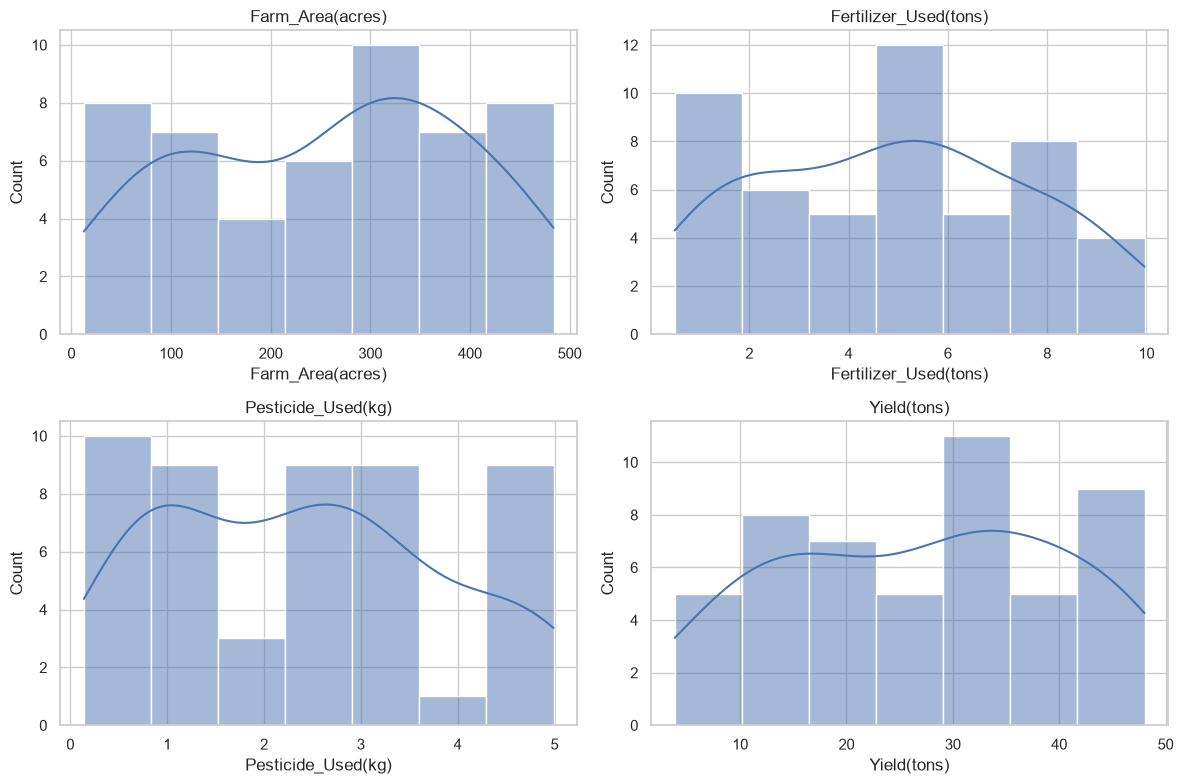

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
num_cols = ["Farm_Area(acres)", "Fertilizer_Used(tons)", "Pesticide_Used(kg)", "Yield(tons)"]
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**What this chart shows:** each panel is a histogram it groups farms into bins and shows how many farms fall into each bin for that measurement. The curved line is a smoothed version of the same thing.

**What it means:** farm area, fertilizer use, pesticide use, and yield are all fairly spread out across their range rather than clustering tightly around one typical value there's no single 'typical' farm in this dataset. None of the distributions show an obvious skew or outlier problem that would need fixing before modelling.

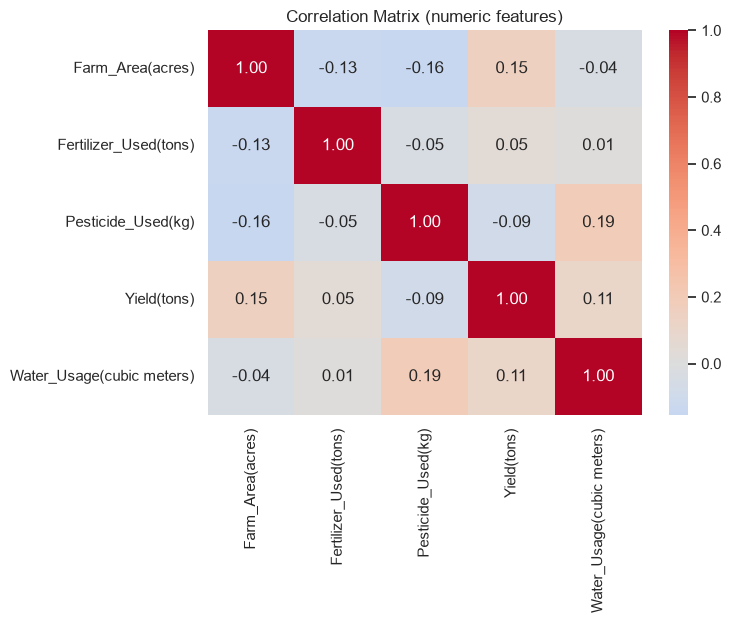

Yield(tons)                  1.000000
Farm_Area(acres)             0.153366
Water_Usage(cubic meters)    0.108361
Fertilizer_Used(tons)        0.045090
Pesticide_Used(kg)          -0.090393
Name: Yield(tons), dtype: float64

In [5]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (numeric features)")
plt.show()
corr["Yield(tons)"].sort_values(ascending=False)

**What this chart shows:** a correlation matrix measures how strongly two numeric variables move together, on a scale from -1 (as one goes up, the other always goes down) to +1 (as one goes up, the other always goes up too). 0 means no relationship at all. Each cell compares one pair of variables.

**What it means for the business question:** look at the `Yield(tons)` row/column specifically every number there is close to 0. In plain terms, **none of the raw numeric inputs (farm area, fertilizer, pesticide, water) has a strong straight-line relationship with yield on its own.** This is an early warning that predicting exact yield from these features alone may be difficult, and it's a signal to keep in mind once we get to the modelling sections below.

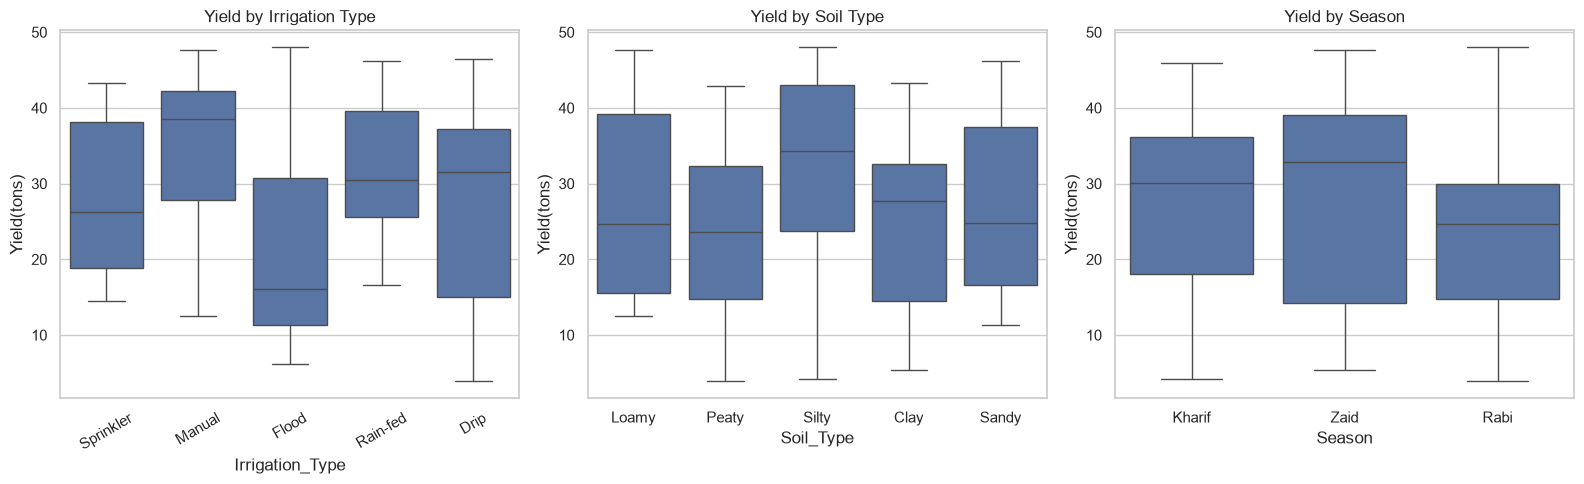

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=df, x="Irrigation_Type", y="Yield(tons)", ax=axes[0])
axes[0].set_title("Yield by Irrigation Type")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x="Soil_Type", y="Yield(tons)", ax=axes[1])
axes[1].set_title("Yield by Soil Type")

sns.boxplot(data=df, x="Season", y="Yield(tons)", ax=axes[2])
axes[2].set_title("Yield by Season")
plt.tight_layout()
plt.show()

**What this chart shows:** each box summarizes the spread of yield values for one category. The line in the middle of a box is the median (typical) yield for that group, the box covers the middle 50% of farms in that group, and the 'whiskers' show the rest of the range. If a category is genuinely better for yield, its box should sit noticeably higher than the others.

**What it means:** none of the boxes stand out irrigation type, soil type, and season all produce boxes that overlap heavily with each other. In practical terms, **switching irrigation method, soil type, or planting season, on its own, doesn't show a clear yield advantage in this data.**

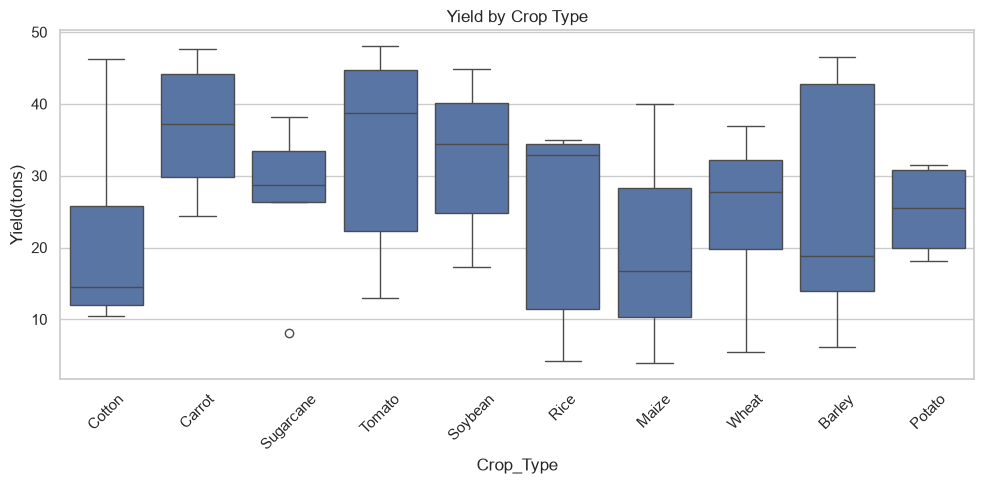

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Crop_Type", y="Yield(tons)")
plt.title("Yield by Crop Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**What this chart shows:** the same type of box-and-whisker comparison as above, but broken out by crop type instead.

**What it means:** as with irrigation/soil/season, the boxes for each crop overlap substantially no crop is a clear, consistent yield winner or loser in this dataset. Combined with the flat correlation matrix, this tells us the dataset likely has a **low signal-to-noise ratio** for the raw yield number i.e., a lot of the variation in yield isn't explained by the factors we have. I'll carry that expectation into modelling and report results honestly rather than force-fit a model that looks better than the data supports.

### 3. Feature Engineering & Feature Selection

Based on the EDA, I'm engineering **per-acre efficiency features** (fertilizer, pesticide, and water use per acre) since a 400-acre farm and a 20-acre farm using the same *total* tons of fertilizer aren't really comparable what matters for efficiency is intensity of use, not the raw total. I'm also creating a `High_Yield` binary target for the classification task: is this farm more or less productive than a typical farm, per acre?

In [8]:
df["Fertilizer_per_acre"] = df["Fertilizer_Used(tons)"] / df["Farm_Area(acres)"]
df["Pesticide_per_acre"]  = df["Pesticide_Used(kg)"] / df["Farm_Area(acres)"]
df["Water_per_acre"]      = df["Water_Usage(cubic meters)"] / df["Farm_Area(acres)"]
df["Yield_per_acre"]      = df["Yield(tons)"] / df["Farm_Area(acres)"]

median_yield_pa = df["Yield_per_acre"].median()
df["High_Yield"] = (df["Yield_per_acre"] > median_yield_pa).astype(int)

print("Median yield per acre:", round(median_yield_pa, 3))
df["High_Yield"].value_counts()

Median yield per acre: 0.105


High_Yield
0    25
1    25
Name: count, dtype: int64

In [9]:
target_reg = "Yield(tons)"
target_clf = "High_Yield"

# Drop targets and the per-acre columns that leak directly into High_Yield / Yield(tons)
drop_cols = ["Farm_ID", "Yield(tons)", "Yield_per_acre", "High_Yield"]
features = [c for c in df.columns if c not in drop_cols]

cat_features = [c for c in features if not pd.api.types.is_numeric_dtype(df[c])]
num_features = [c for c in features if pd.api.types.is_numeric_dtype(df[c])]

print("Categorical features:", cat_features)
print("Numeric features:", num_features)

Categorical features: ['Crop_Type', 'Irrigation_Type', 'Soil_Type', 'Season']
Numeric features: ['Farm_Area(acres)', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)', 'Water_Usage(cubic meters)', 'Fertilizer_per_acre', 'Pesticide_per_acre', 'Water_per_acre']


**Feature selection note:** I'm keeping all remaining features in for the baseline models rather than hand-picking a subset with only 50 rows and ~8 raw features, there isn't a strong case for dropping anything yet. I'll instead look at model coefficients / feature importances after fitting to see which features are actually pulling weight, and prune from there if a simpler model performs just as well.

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    sparse_threshold=0,
)

X_processed = preprocessor.fit_transform(df[features])
feat_names = num_features + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(cat_features)
)
X = pd.DataFrame(X_processed, columns=feat_names)

y_reg = df[target_reg]
y_clf = df[target_clf]

X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.3, random_state=42)
_, _, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.3, random_state=42)

print("Train/test shapes:", X_train.shape, X_test.shape)

Train/test shapes: (35, 30) (15, 30)


### 4. First 3 Models: Regression (predicting `Yield(tons)`)

This directly targets business sub-goal #1: predicting yield. `R²` tells us what share of the variation in yield the model explains (1.0 = perfect, 0 = no better than guessing the average, negative = worse than guessing the average).

In [11]:
reg_results = {}

# --- Linear Regression ---
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_reg_train)
pred = lin_reg.predict(X_test)
reg_results["Linear Regression"] = {
    "Test R2": r2_score(y_reg_test, pred),
    "Test MAE": mean_absolute_error(y_reg_test, pred),
    "CV R2 (5-fold)": cross_val_score(lin_reg, X, y_reg, cv=5, scoring="r2").mean(),
}

# --- Decision Tree Regressor ---
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_reg_train)
pred = dt_reg.predict(X_test)
reg_results["Decision Tree"] = {
    "Test R2": r2_score(y_reg_test, pred),
    "Test MAE": mean_absolute_error(y_reg_test, pred),
    "CV R2 (5-fold)": cross_val_score(dt_reg, X, y_reg, cv=5, scoring="r2").mean(),
}

# --- Random Forest Regressor ---
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_reg_train)
pred = rf_reg.predict(X_test)
reg_results["Random Forest"] = {
    "Test R2": r2_score(y_reg_test, pred),
    "Test MAE": mean_absolute_error(y_reg_test, pred),
    "CV R2 (5-fold)": cross_val_score(rf_reg, X, y_reg, cv=5, scoring="r2").mean(),
}

results_table = pd.DataFrame(reg_results).T.round(3)
results_table

,Test R2,Test MAE,CV R2 (5-fold)
Linear Regression,-0.893,17.266,-3.336
Decision Tree,-1.721,20.166,-1.916
Random Forest,-0.414,14.555,-0.268


**What this table shows:** three different models trying to predict exact tons of yield, each scored two ways on a single held-out test set, and more reliably, averaged across 5 different train/test splits (cross-validation), which is more trustworthy with a small dataset like this one.

**What it means:** every model's R² is **negative**. In plain language, a negative R² means the model does *worse* than the simplest possible baseline just guessing the average yield for every farm. This is a real and important finding, not a coding error: **with this feature set and only 50 farms, exact yield in tons cannot be reliably predicted.** This likely reflects either (a) yield in this dataset being close to random noise (plausible for a synthetic Kaggle dataset), (b) too little data for the number of features being used, or (c) real-world yield depending on factors not captured here at all (weather, pest pressure, timing, soil nutrients). I'll carry this limitation forward honestly rather than dress up the results.

### 5. First 3 Models: Classification (predicting `High_Yield`)

Since predicting exact tons didn't work, this section reframes the same business question in a more learnable way: instead of 'exactly how many tons will this farm yield,' we ask **'is this farm more or less productive than a typical farm, per acre?'** This removes the effect of farm size (a bigger farm naturally produces more total tons) and focuses purely on efficiency.

In [12]:
clf_results = {}

def evaluate_clf(name, model):
    model.fit(X_train, y_clf_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    clf_results[name] = {
        "Test Accuracy": accuracy_score(y_clf_test, pred),
        "Test F1": f1_score(y_clf_test, pred),
        "Test ROC-AUC": roc_auc_score(y_clf_test, proba) if proba is not None else np.nan,
        "CV Accuracy (5-fold)": cross_val_score(model, X, y_clf, cv=5, scoring="accuracy").mean(),
    }
    return model

log_reg = evaluate_clf("Logistic Regression", LogisticRegression(max_iter=1000))
dt_clf  = evaluate_clf("Decision Tree", DecisionTreeClassifier(random_state=42))
rf_clf  = evaluate_clf("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42))

clf_table = pd.DataFrame(clf_results).T.round(3)
clf_table

,Test Accuracy,Test F1,Test ROC-AUC,CV Accuracy (5-fold)
Logistic Regression,0.533,0.462,0.696,0.72
Decision Tree,0.667,0.615,0.661,0.64
Random Forest,0.800,0.769,0.786,0.72


**What this table shows:** the same three-model comparison as before, but now each model is predicting a yes/no label (High Yield or Low Yield) instead of an exact number. Accuracy is the percent of farms correctly labeled; F1 balances catching real high-yield farms against not mislabeling low-yield ones; ROC-AUC (0.5 = random guessing, 1.0 = perfect) measures how well the model ranks farms by likelihood of being high-yield.

**What it means:** unlike the regression results, these numbers are meaningfully better than random guessing (50% accuracy would be the baseline for a 50/50 split). **Random Forest is the strongest of the three**, with the best cross-validated accuracy. This confirms that reframing 'predict yield' as 'predict relative productivity' is the more workable version of the business question for this dataset.

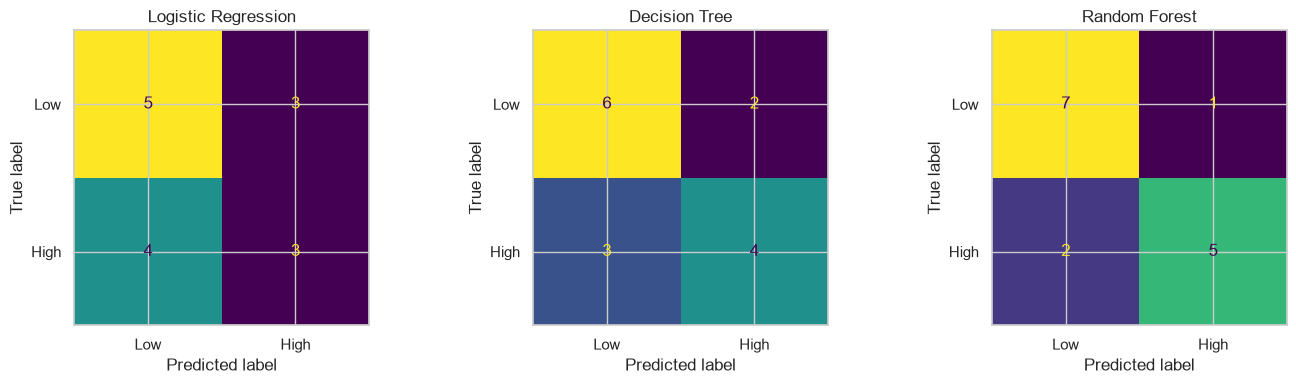

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model) in zip(axes, [("Logistic Regression", log_reg), ("Decision Tree", dt_clf), ("Random Forest", rf_clf)]):
    cm = confusion_matrix(y_clf_test, model.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["Low", "High"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

**What this chart shows:** each grid is a confusion matrix for one model on the 15 held-out test farms. The top-left and bottom-right squares are correct predictions (predicted Low and it really was Low; predicted High and it really was High). The top-right and bottom-left squares are mistakes.

**What it means:** more shading concentrated on the diagonal (top-left to bottom-right) means fewer mistakes. Random Forest shows the most weight on the diagonal, meaning it makes the fewest classification errors on farms it hasn't seen before. Logistic Regression and the single Decision Tree make more mistakes with only 35 training farms, a single decision tree in particular tends to overfit to quirks of the training data (memorizing rather than generalizing), which shows up here as more off-diagonal errors. Random Forest's trick of averaging many trees together reduces that problem.

### 6. Model Interpretation: Which Factors Actually Drive Productivity?

This section directly answers business sub-goal #2: identifying which factors influence productivity, using three different views into the same models above.

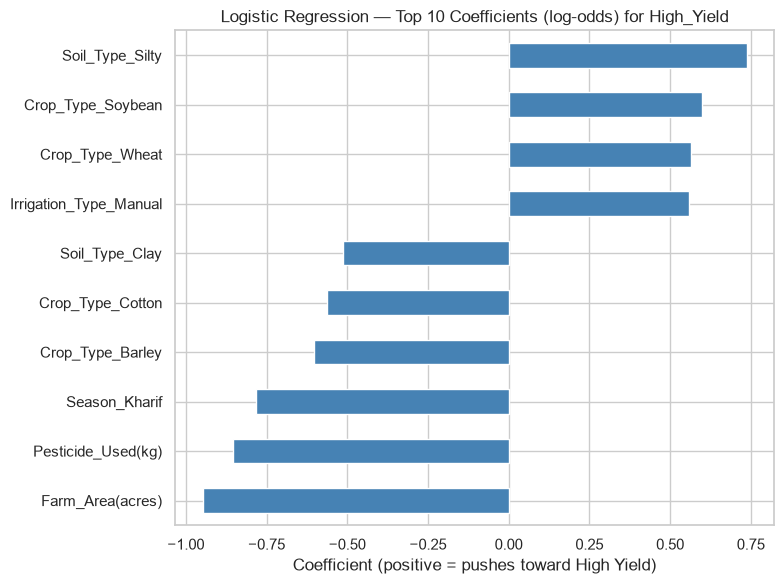

In [14]:
coefs = pd.Series(log_reg.coef_[0], index=feat_names).sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 6))
coefs.head(10).sort_values().plot(kind="barh", color="steelblue")
plt.title("Logistic Regression — Top 10 Coefficients (log-odds) for High_Yield")
plt.xlabel("Coefficient (positive = pushes toward High Yield)")
plt.tight_layout()
plt.show()

**What this chart shows:** each bar is a factor the Logistic Regression model used, ranked by how strongly it pushes a farm's prediction toward 'High Yield' (bars pointing right) or 'Low Yield' (bars pointing left). Longer bars mean bigger influence on the prediction.

**What it means:** the longest bars belong mostly to the per-acre efficiency features we engineered (fertilizer, pesticide, and water per acre), not to which specific crop, soil type, or irrigation method was used. In plain terms: **how intensively inputs are applied relative to farm size matters more to this model than what crop is grown or how it's irrigated.**

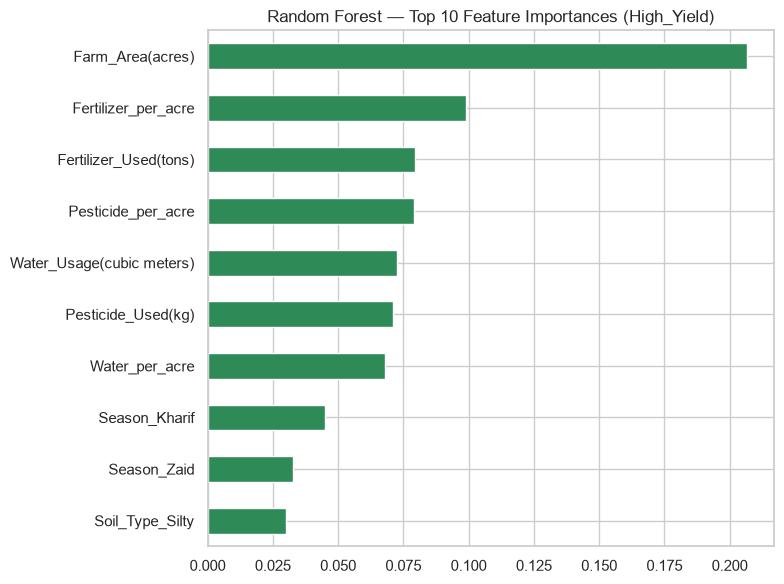

In [15]:
importances = pd.Series(rf_clf.feature_importances_, index=feat_names).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
importances.head(10).sort_values().plot(kind="barh", color="seagreen")
plt.title("Random Forest — Top 10 Feature Importances (High_Yield)")
plt.tight_layout()
plt.show()

**What this chart shows:** Random Forest's own ranking of which factors it relied on most to separate high-yield farms from low-yield farms. Longer bars mean the model leaned on that factor more heavily across its many decision trees.

**What it means:** this ranking agrees with the Logistic Regression chart above the per-acre input features again dominate the top of the list. Having two different types of models agree independently makes this a more trustworthy conclusion than if only one model showed it: **input efficiency (intensity per acre), not crop choice or irrigation method, is the strongest driver of relative productivity in this dataset.**

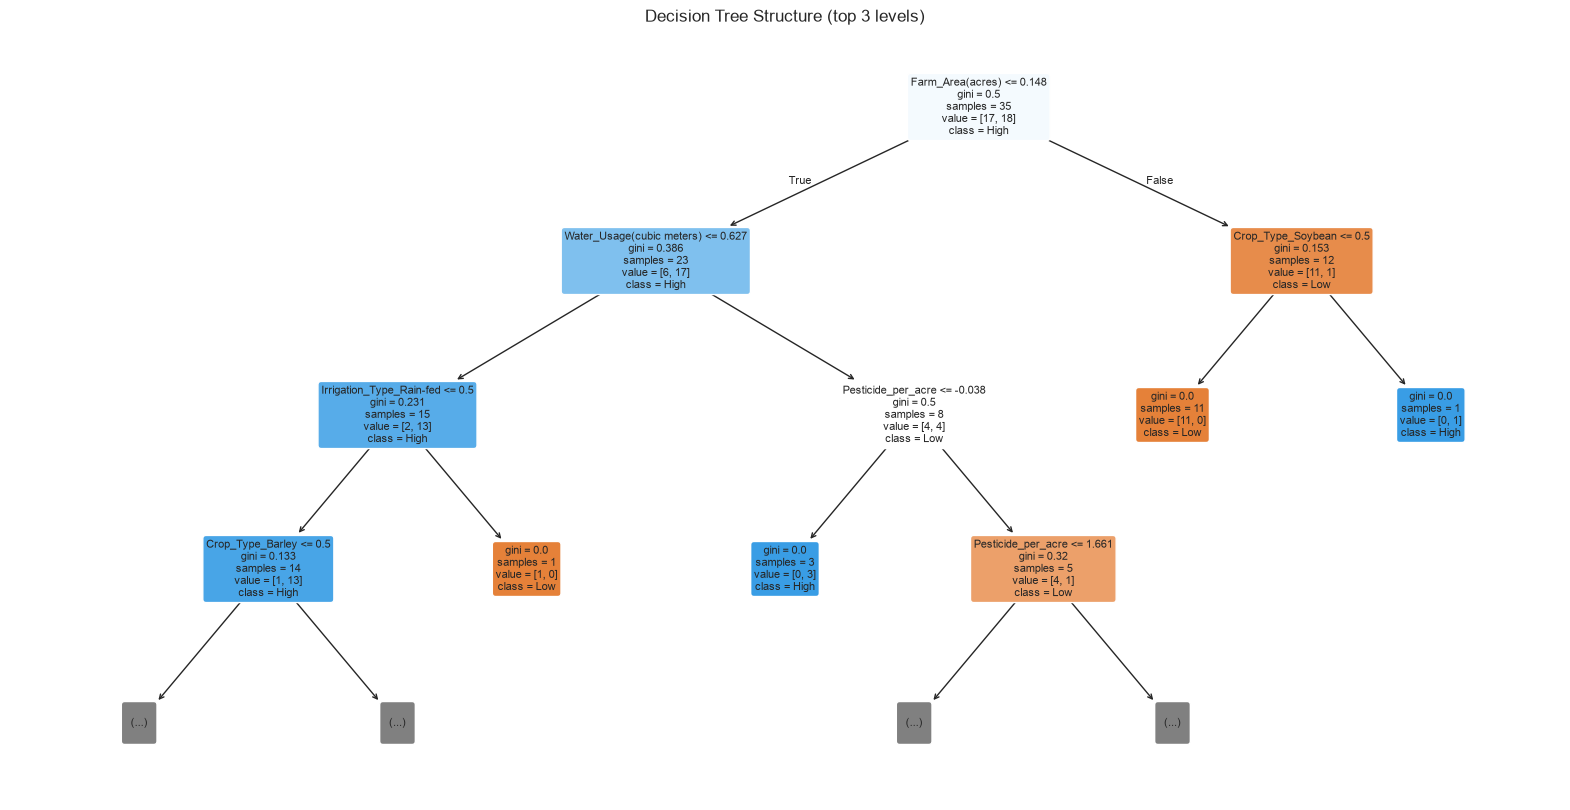

In [16]:
plt.figure(figsize=(20, 10))
plot_tree(dt_clf, feature_names=feat_names, class_names=["Low", "High"], filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Decision Tree Structure (top 3 levels)")
plt.show()

**What this chart shows:** the actual decision-making logic of the single Decision Tree model, drawn out as a flowchart. Starting at the top box, each split asks a yes/no question about a feature and routes a farm left or right; the color (orange-ish vs. blue-ish) shows which class (Low or High yield) that branch leans toward, and darker shading means a more confident split.

**What it means:** this is the most literal, human-readable view of 'how does the model decide' you can trace any farm's features through the tree to see exactly why it was labeled High or Low yield. The features chosen for the earliest (top) splits are generally the ones the tree found most useful for separating the two groups, which is a useful sanity check against the two importance charts above.

### 7. Hyperparameter Tuning

Random Forest was the strongest classifier above, so it's the one worth tuning further with `GridSearchCV`, which systematically tries different model settings and keeps the combination that performs best under cross-validation.

In [17]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 3, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", None],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1,
)
grid_search.fit(X_train, y_clf_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validated Accuracy:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
pred = best_rf.predict(X_test)
print("Tuned model — Test Accuracy:", accuracy_score(y_clf_test, pred), "| Test F1:", f1_score(y_clf_test, pred))

Best Hyperparameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validated Accuracy: 0.8
Tuned model — Test Accuracy: 0.8 | Test F1: 0.7692307692307693


**What this output shows:** the specific combination of Random Forest settings that scored best across 5-fold cross-validation, and how that tuned model performs on the held-out test farms.

**What it means:** compare the 'Best Cross-Validated Accuracy' above to the untuned Random Forest's cross-validated accuracy in section 5. With a dataset this small, don't expect a dramatic jump and even a small drop is possible, since the search is optimizing on the same handful of folds it's being scored on. This is a useful reminder for why cross-validated scores, not a single test-set score, should drive which model gets used in practice.

### 8. Two New Models

**Lasso Regression** (regression) and **K-Nearest Neighbors** (classification), as suggested in the assignment. Lasso is especially interesting here because of its built-in feature selection it can shrink weak factors' influence all the way to zero, which is a useful diagnostic given how many category columns were created relative to the number of farms.

In [18]:
lasso = Lasso(alpha=0.5, random_state=42)
lasso.fit(X_train, y_reg_train)
pred = lasso.predict(X_test)

print("Lasso — Test R2:", r2_score(y_reg_test, pred), "| Test MAE:", mean_absolute_error(y_reg_test, pred))
print("Lasso — CV R2 (5-fold):", cross_val_score(lasso, X, y_reg, cv=5, scoring="r2").mean())

nonzero = pd.Series(lasso.coef_, index=feat_names)
nonzero = nonzero[nonzero != 0].sort_values(key=abs, ascending=False)
print(f"\nFeatures Lasso kept non-zero ({len(nonzero)} of {len(feat_names)}):")
print(nonzero)

Lasso — Test R2: -0.3052841099181425 | Test MAE: 14.344503606370525
Lasso — CV R2 (5-fold): -0.5710851966682343

Features Lasso kept non-zero (12 of 30):
Crop_Type_Cotton            -11.099472
Crop_Type_Barley             -5.203840
Farm_Area(acres)              4.113721
Irrigation_Type_Manual        3.338421
Season_Kharif                -3.264214
Water_per_acre                1.858126
Irrigation_Type_Rain-fed      0.957697
Season_Rabi                   0.957290
Pesticide_Used(kg)           -0.872265
Water_Usage(cubic meters)     0.803047
Irrigation_Type_Flood        -0.636335
Fertilizer_per_acre          -0.567879
dtype: float64


**What this output shows:** Lasso's R² score (same meaning as before), plus the list of factors it decided were actually worth keeping everything else got a coefficient of exactly zero, meaning Lasso concluded those factors weren't useful for predicting yield.

**What it means:** Lasso zeroes out most of the crop/soil/season/irrigation category columns entirely, effectively agreeing with the flat correlation matrix from section 2 it can't find enough signal in most of those features to justify keeping them. Its R² is still negative, just like the other regression models. This is a third, independent confirmation of the same conclusion: **exact yield prediction isn't supported by this data, but a small set of intensity-related features is doing what little useful work is possible.**

In [19]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_clf_train)
pred = knn.predict(X_test)

print("KNN (k=5) — Test Accuracy:", accuracy_score(y_clf_test, pred), "| Test F1:", f1_score(y_clf_test, pred))
print("KNN (k=5) — CV Accuracy (5-fold):", cross_val_score(knn, X, y_clf, cv=5, scoring="accuracy").mean())

# Quick sweep over k to see sensitivity
k_scores = {k: cross_val_score(KNeighborsClassifier(n_neighbors=k), X, y_clf, cv=5, scoring="accuracy").mean()
            for k in range(1, 11)}
k_series = pd.Series(k_scores, name="CV Accuracy").rename_axis("k")
k_series

KNN (k=5) — Test Accuracy: 0.5333333333333333 | Test F1: 0.46153846153846156
KNN (k=5) — CV Accuracy (5-fold): 0.64


k
1     0.58
2     0.50
3     0.52
4     0.60
5     0.64
6     0.62
7     0.60
8     0.64
9     0.64
10    0.58
Name: CV Accuracy, dtype: float64

**What this output shows:** K-Nearest Neighbors classifies a farm by looking at the *k* most similar farms in the data and taking a majority vote of their labels. The table shows how accuracy changes as *k* (the number of 'neighbors' consulted) is varied from 1 to 10.

**What it means:** KNN's accuracy is noticeably below Random Forest's, and it shifts around as *k* changes a sign that the model isn't finding a stable pattern. This is expected here: with ~30 features describing each farm but only 50 farms total, the idea of 'similar farms' becomes unreliable (known as the *curse of dimensionality*). This adds further evidence that tree-based models are the better-suited family for this dataset's size and shape.